# Calendar Aging Analysis — DV2 Storage Study (checkpoint exclusion + day adjustment + v3 metrics)

Builds a six-panel summary figure (discharge capacity, discharge energy,
coulombic efficiency, SOH, round-trip efficiency, and relative RTE — all
vs. days in storage) and an ensemble-data Excel export, from two source
workbooks:

1. **Raw capacity/energy grading data** — one row per cell, one block of
   columns per storage checkpoint (baseline + 14/28 days, 2-6 months).
2. **Storage-time tracker** — the actual storage/return dates for each
   temperature and checkpoint, used to convert checkpoint labels into
   real elapsed days.

This version keeps the checkpoint **exclusion list** (`EXCLUDED_BUCKETS`)
and **day adjustment** (`EXCLUSION_TEMPERATURES`) from `exclusion_v2`
unchanged — the six-panel figure in Step 5 is identical to v2.

What's new in v3 is the **exported ensemble workbook's column set**
(Step 6), which replaces the old `Charge/Discharge capacity` pairing with
an explicit split between:

- **Retained** Discharge Capacity/Energy — measured straight out of
  storage, *before* the checkup recharge (captures self-discharge)
- **Recovered** Charge/Discharge Capacity/Energy — the checkup
  recharge-then-discharge cycle (what the old export called
  "Charge/Discharge capacity/energy")

plus a new **Self Discharge (Ah)** metric, and renamed ΔV/DCR/thickness
columns that are still unavailable for this calendar test and stay `NAN`.

Update the paths in the **Configuration** cell if the source files move.

In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---------------------------------------------------------
RAW_DATA_PATH = Path(
    r"C:\Users\DanWindsor\OneDrive - Peak Energy\Documents\MCM_DataConversion"
    r"\20260728_CaLT_MCM_HT-B\20260611_Storage Data for DV2 A_HXcorrected_translated.xlsx"
)
STORAGE_TIME_PATH = Path(
    r"C:\Users\DanWindsor\OneDrive - Peak Energy\Documents\MCM_DataConversion"
    r"\20260728_CaLT_MCM_HT-B\20260417_Attachment 2.  Storage time_corrected_DW-HX.xlsx"
)

RAW_DATA_SHEET = "Storage Summary"
STORAGE_TIME_SHEET = "Storage"

# Storage checkpoints, in the order they appear in BOTH source files.
BUCKET_LABELS = ["14 Days", "28 Days", "2 Months", "3 Months",
                 "4 Months", "5 Months", "6 Months"]

# Checkpoints to exclude from the aggregated summary, the figure, and the
# exported ensemble workbook (e.g. a bad/anomalous checkup). Entries must
# match BUCKET_LABELS exactly (or "Baseline"). Leave empty to include
# everything. The full, unfiltered per-cell data is still written to CSV
# below regardless of this setting.
#   Example: EXCLUDED_BUCKETS = ["28 Days", "5 Months"]
EXCLUDED_BUCKETS = ["4 Months"]

# Which temperatures EXCLUDED_BUCKETS applies to (in °C). Checkpoints for
# any temperature NOT listed here are always kept, even if they appear in
# EXCLUDED_BUCKETS, and their elapsed-day counts are never adjusted.
# Default excludes only 45°C and 60°C, leaving 25°C untouched.
EXCLUSION_TEMPERATURES = [45, 60]

OUTPUT_DIR = Path(r"C:\Users\DanWindsor\OneDrive - Peak Energy\Python\DSW_PythonScripts\MCM_CaLT")
FIGURE_PATH = OUTPUT_DIR / "calendar_aging_summary_exclusion_v3.png"
TIDY_CSV_PATH = OUTPUT_DIR / "calendar_aging_tidy_data_exclusion_v3.csv"
ENSEMBLE_XLSX_PATH = OUTPUT_DIR / "calendar_aging_ensemble_data_exclusion_v6.xlsx"

plt.rcParams["figure.dpi"] = 110


def temp_to_num(temp_str):
    return int(re.sub(r"[^0-9]", "", str(temp_str)))


def soc_to_num(soc_str):
    # Matches "100% SOC", "100%SOC", and "100SOC" (no "%" at all, seen in
    # some machine-translated source files) so this survives formatting
    # drift between source-file versions.
    match = re.search(r"(\d+)\s*%?\s*SOC", str(soc_str), re.IGNORECASE)
    return int(match.group(1)) if match else None

## Step 1 — Elapsed days per temperature / checkpoint

The storage-time tracker records a *storage date* (cells go into the
chamber) and a *split delivery date* (cells come out for check-up) for
each checkpoint, separately for the *planned* and *actual* schedule, for
each of the three temperatures. We use the **actual** dates and compute
days elapsed since the first storage date at that temperature. This is
the *unadjusted* day count — the exclusion-based adjustment happens in
Step 3.5, once we know which checkpoints are actually being excluded.

In [ ]:
def parse_storage_days(path, sheet, bucket_labels):
    """Cumulative elapsed days (from the first storage date) for each
    temperature and storage checkpoint, based on actual completion dates."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    # Locate the "completion date" label column by its content rather than
    # a fixed index -- its position has shifted between source-file
    # versions. Temperature sits one column to its left, and the first
    # storage-date column sits one column to its right, in every version
    # seen so far.
    label_mask = raw.isin(["Actual completion date", "planned completion date"])
    label_cols = label_mask.any(axis=0)
    if not label_cols.any():
        raise ValueError(
            f"Could not find an 'Actual completion date' row in sheet {sheet!r} "
            f"of {path} -- the storage-time tracker's layout may have changed."
        )
    label_col = label_cols[label_cols].index[0]
    temp_col = label_col - 1
    first_storage_col = label_col + 1

    # Temperature label is only populated on the first ("planned") row of
    # each temperature's pair of rows -> forward-fill it downward.
    raw[temp_col] = raw[temp_col].ffill()

    storage_cols = list(range(first_storage_col, first_storage_col + 2 * len(bucket_labels), 2))
    split_cols = [c + 1 for c in storage_cols]

    actual_rows = raw[raw[label_col] == "Actual completion date"]

    days_map = {}
    for _, row in actual_rows.iterrows():
        temperature = row[temp_col]
        t0 = row[storage_cols[0]]
        if pd.isna(t0):
            continue
        t0 = pd.Timestamp(t0)

        days = []
        for split_col in split_cols:
            split_date = row[split_col]
            days.append(np.nan if pd.isna(split_date) else (pd.Timestamp(split_date) - t0).days)
        days_map[temperature] = days

    return days_map


days_map = parse_storage_days(STORAGE_TIME_PATH, STORAGE_TIME_SHEET, BUCKET_LABELS)

days_table = pd.DataFrame(days_map, index=BUCKET_LABELS).T
days_table.index.name = "Temperature"
print("Cumulative days-in-study (unadjusted), by temperature and storage checkpoint:")
display(days_table)

# Sanity check — elapsed days should increase monotonically within a temperature.
for temperature, days in days_map.items():
    valid = [d for d in days if pd.notna(d)]
    if any(np.diff(valid) <= 0) or any(d < 0 for d in valid):
        warnings.warn(
            f"Non-monotonic or negative elapsed days for {temperature}: {days}. "
            "Check the storage/split-delivery dates in the source spreadsheet "
            "for typos (e.g. a wrong year)."
        )

## Step 2 — Parse the raw capacity/energy data

Each row is one cell. Columns are grouped into a baseline "Capacity
Grading Data" block, then one "After &lt;checkpoint&gt; Storage" block per
checkpoint. Within each storage block we now pull out three distinct
measurements:

- **Retained** Capacity/Energy — "① Remaining Capacity/Energy", the
  discharge measured straight out of storage, before any recharge.
  Not applicable at Baseline (no prior storage) or for 0%-SOC cells
  (already at 0%, nothing to measure).
- **Recovered Charge** Capacity/Energy — "② Charge Capacity/Energy", the
  checkup recharge.
- **Recovered Discharge** Capacity/Energy — "③ Recovered Capacity/Energy",
  the full checkup discharge — comparable across checkpoints and SOC
  groups, same as the baseline discharge capacity/energy.

We also pull the "④ SOC Adjustment Charge Capacity" — the charge applied
*after* this checkup to set the SOC for the *next* storage interval (and,
for Baseline, the "③ SOC Adjustment Charge Capacity" that sets the SOC for
the *first* storage interval) — needed to compute Self Discharge in Step 3.

In [ ]:
def load_raw_metrics(path, sheet, bucket_labels):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    block_titles = raw.iloc[1]

    body = raw.iloc[3:].copy()
    body[1] = body[1].ffill()  # Temperature
    body[2] = body[2].ffill()  # Group + SOC label
    body = body.rename(columns={1: "Temperature", 2: "SOC_Group", 3: "CellNo", 4: "CellID"})
    body = body.dropna(subset=["CellID"]).reset_index(drop=True)

    # Baseline block has been titled "Capacity Grading Data" and, in newer
    # source files, "Capacity Calibration Data" -- match either wording.
    baseline_matches = block_titles[
        block_titles.astype(str).str.contains("Capacity Grading|Capacity Calibration", na=False, regex=True)
    ]
    if baseline_matches.empty:
        raise ValueError(
            "Could not find the baseline 'Capacity Grading/Calibration Data' "
            "block header -- the raw data workbook's layout may have changed."
        )
    baseline_start = baseline_matches.index[0]
    storage_starts = block_titles[
        block_titles.astype(str).str.startswith("After", na=False)
    ].index.tolist()

    assert len(storage_starts) == len(bucket_labels), (
        f"Found {len(storage_starts)} 'After ...' blocks in the header but "
        f"{len(bucket_labels)} bucket labels are configured — update BUCKET_LABELS."
    )

    records = []
    for _, row in body.iterrows():
        records.append(dict(
            Temperature=row["Temperature"], SOC_Group=row["SOC_Group"],
            CellID=row["CellID"], Bucket=0, BucketLabel="Baseline",
            RetainedDischargeCapacity_Ah=np.nan,          # no prior storage at Baseline
            ChargeCapacity_Ah=row[baseline_start],         # "1 Charge Capacity" (Recovered Charge)
            DischargeCapacity_Ah=row[baseline_start + 1],  # "2 Discharge Capacity" (Recovered Discharge)
            RetainedDischargeEnergy_Wh=np.nan,
            ChargeEnergy_Wh=row[baseline_start + 2],       # "1 Charge Energy" (Recovered Charge)
            DischargeEnergy_Wh=row[baseline_start + 3],    # "2 Discharge Energy" (Recovered Discharge)
            NextPeriodSOCAdjChargeCapacity_Ah=row[baseline_start + 4],  # "3 SOC Adjustment Charge Capacity"
        ))

        for i, (start, label) in enumerate(zip(storage_starts, bucket_labels), start=1):
            records.append(dict(
                Temperature=row["Temperature"], SOC_Group=row["SOC_Group"],
                CellID=row["CellID"], Bucket=i, BucketLabel=label,
                RetainedDischargeCapacity_Ah=row[start],       # "1 Remaining Capacity"
                ChargeCapacity_Ah=row[start + 1],               # "2 Charge Capacity" (Recovered Charge)
                DischargeCapacity_Ah=row[start + 2],            # "3 Recovered Capacity" (Recovered Discharge)
                RetainedDischargeEnergy_Wh=row[start + 3],      # "1 Remaining Energy"
                ChargeEnergy_Wh=row[start + 4],                 # "2 Charge Energy" (Recovered Charge)
                DischargeEnergy_Wh=row[start + 5],              # "3 Recovered Energy" (Recovered Discharge)
                NextPeriodSOCAdjChargeCapacity_Ah=row[start + 6],  # "4 SOC Adjustment Charge Capacity"
            ))

    return pd.DataFrame.from_records(records)


# NOTE: rows are already in the correct order here — load_raw_metrics()
# iterates cells in original file order (matching the "No." column) and
# appends each cell's checkpoints in Bucket order 0..7. A global sort by
# CellID would scramble that original cell ordering (CellIDs like
# "DV2A074" don't sort the same way "No." 1..27 does), which would then
# mislabel the "Cell 1..27" sheets in Step 6. groupby(...).shift(1) in
# Step 3 respects each group's existing row order regardless, so no sort
# is needed for that either.
tidy = load_raw_metrics(RAW_DATA_PATH, RAW_DATA_SHEET, BUCKET_LABELS)
print(f"Parsed {tidy['CellID'].nunique()} cells x {tidy['Bucket'].nunique()} checkpoints "
      f"= {len(tidy)} rows")
tidy.head(10)

## Step 3 — Derived metrics

- **Coulombic Efficiency** = Recovered Discharge Capacity / Recovered Charge Capacity
- **Energy Efficiency** (RTE) = Recovered Discharge Energy / Recovered Charge Energy
- **Relative Discharge Capacity** (SOH) = Recovered Discharge Capacity(t) / Recovered Discharge Capacity(Day 0), per cell
- **Relative Energy Efficiency** = Energy Efficiency(t) / Energy Efficiency(Day 0), per cell
- **Relative Retained Discharge Capacity/Energy** = Retained Discharge Capacity/Energy(t) / Recovered Discharge Capacity/Energy(Day 0), per cell
- **Relative Discharge Energy** = Recovered Discharge Energy(t) / Recovered Discharge Energy(Day 0), per cell
- **Energy Inefficiency** = 1 − Energy Efficiency; **Relative Energy Inefficiency** = Energy Inefficiency(t) / Energy Inefficiency(Day 0)
- **Self Discharge (Ah)** = (SOC-Adjustment Charge Capacity applied *before* this storage interval, i.e. the previous checkpoint's value for the same cell) − (Retained Discharge Capacity measured *after* this interval). `NaN` at Baseline (no prior interval) and for 0%-SOC cells (no adjustment charge is ever applied, so there's nothing to subtract from).

All ratios here are unitless fractions (~1.00), matching the ensemble
export's convention. The `_%`-suffixed columns are kept for the Step 5
figure exactly as in v2. Days-in-storage from Step 1 (unadjusted) are
attached per Temperature + checkpoint; the CSV written here is the full,
unfiltered, unadjusted dataset for audit purposes.

In [19]:
# --- Metrics used by the Step 5 figure (unchanged from v2) -----------------
tidy["CoulombicEfficiency_%"] = tidy["DischargeCapacity_Ah"] / tidy["ChargeCapacity_Ah"] * 100
tidy["RTE_%"] = tidy["DischargeEnergy_Wh"] / tidy["ChargeEnergy_Wh"] * 100

baseline_capacity = tidy.loc[tidy["Bucket"] == 0].set_index("CellID")["DischargeCapacity_Ah"]
baseline_rte = tidy.loc[tidy["Bucket"] == 0].set_index("CellID")["RTE_%"]

tidy["SOH_%"] = tidy["DischargeCapacity_Ah"] / tidy["CellID"].map(baseline_capacity) * 100
tidy["RelativeRTE_%"] = tidy["RTE_%"] / tidy["CellID"].map(baseline_rte) * 100


def lookup_days(row):
    if row["Bucket"] == 0:
        return 0.0
    bucket_days = days_map.get(row["Temperature"])
    if bucket_days is None:
        return np.nan
    return bucket_days[row["Bucket"] - 1]


tidy["Days"] = tidy.apply(lookup_days, axis=1)

# --- New v3 metrics used by the ensemble export (Step 6) -------------------
baseline_energy = tidy.loc[tidy["Bucket"] == 0].set_index("CellID")["DischargeEnergy_Wh"]

tidy["SelfDischarge_Ah"] = (
    tidy.groupby("CellID")["NextPeriodSOCAdjChargeCapacity_Ah"].shift(1)
    - tidy["RetainedDischargeCapacity_Ah"]
)

tidy["RelativeRetainedDischargeCapacity"] = tidy["RetainedDischargeCapacity_Ah"] / tidy["CellID"].map(baseline_capacity)
tidy["RelativeDischargeCapacity"] = tidy["SOH_%"] / 100

tidy["RelativeRetainedDischargeEnergy"] = tidy["RetainedDischargeEnergy_Wh"] / tidy["CellID"].map(baseline_energy)
tidy["RelativeDischargeEnergy"] = tidy["DischargeEnergy_Wh"] / tidy["CellID"].map(baseline_energy)

tidy["CoulombicEfficiency_frac"] = tidy["CoulombicEfficiency_%"] / 100
tidy["EnergyEfficiency_frac"] = tidy["RTE_%"] / 100
tidy["EnergyInefficiency_frac"] = 1 - tidy["EnergyEfficiency_frac"]
tidy["RelativeEnergyEfficiency_frac"] = tidy["RelativeRTE_%"] / 100

baseline_energy_ineff = tidy.loc[tidy["Bucket"] == 0].set_index("CellID")["EnergyInefficiency_frac"]
tidy["RelativeEnergyInefficiency_frac"] = tidy["EnergyInefficiency_frac"] / tidy["CellID"].map(baseline_energy_ineff)

# Flag checkpoints that have real capacity/energy data but no usable date
# (i.e. the storage-time tracker hasn't been filled in yet for that
# temperature/checkpoint). These would otherwise silently disappear from
# the plots below.
orphaned = tidy[tidy["DischargeCapacity_Ah"].notna() & tidy["Days"].isna()]
if not orphaned.empty:
    missing = (
        orphaned[["Temperature", "BucketLabel"]]
        .drop_duplicates()
        .to_string(index=False)
    )
    warnings.warn(
        "Capacity/energy data exists for the following Temperature/checkpoint "
        "combinations, but the storage-time tracker has no date for them yet "
        "(so they cannot be placed on the Days axis and will be dropped from "
        f"the figure):\n{missing}"
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tidy.to_csv(TIDY_CSV_PATH, index=False)
print(f"Full (unfiltered, unadjusted) tidy per-cell data written to {TIDY_CSV_PATH}")
tidy.head(10)

Full (unfiltered, unadjusted) tidy per-cell data written to C:\Users\DanWindsor\OneDrive - Peak Energy\Python\DSW_PythonScripts\MCM_CaLT\calendar_aging_tidy_data_exclusion_v3.csv


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_7720\3052368220.py:56: UserWarning: Capacity/energy data exists for the following Temperature/checkpoint combinations, but the storage-time tracker has no date for them yet (so they cannot be placed on the Days axis and will be dropped from the figure):
Temperature BucketLabel
        45℃    6 Months
        60℃    6 Months
  warnings.warn(


,Temperature,SOC_Group,CellID,Bucket,BucketLabel,RetainedDischargeCapacity_Ah,ChargeCapacity_Ah,DischargeCapacity_Ah,RetainedDischargeEnergy_Wh,ChargeEnergy_Wh,...,SelfDischarge_Ah,RelativeRetainedDischargeCapacity,RelativeDischargeCapacity,RelativeRetainedDischargeEnergy,RelativeDischargeEnergy,CoulombicEfficiency_frac,EnergyEfficiency_frac,EnergyInefficiency_frac,RelativeEnergyEfficiency_frac,RelativeEnergyInefficiency_frac
0,25℃,Group A 100% SOC,DV2A165,0,Baseline,NaN,175.945264,175.987246,NaN,521.876312,...,NaN,NaN,1.000000,NaN,1.000000,1.000239,0.969799,0.030201,1.000000,1.000000
1,25℃,Group A 100% SOC,DV2A165,1,14 Days,173.853714,174.196579,174.845078,497.746124,516.691406,...,4.378708,0.987877,0.993510,0.983464,0.991540,1.003723,0.971244,0.028756,1.001490,0.952155
2,25℃,Group A 100% SOC,DV2A165,2,28 Days,173.524536,173.961517,174.670670,497.355042,515.122009,...,1.279907,0.986006,0.992519,0.982692,0.991723,1.004076,0.974382,0.025618,1.004726,0.848240
3,25℃,Group A 100% SOC,DV2A165,3,2 Months,172.518799,173.007233,173.755432,493.960602,512.553772,...,2.117111,0.980291,0.987318,0.975985,0.985817,1.004325,0.973433,0.026567,1.003747,0.879674
4,25℃,Group A 100% SOC,DV2A165,4,3 Months,172.258133,172.643127,173.424225,493.167725,511.353485,...,1.455719,0.978810,0.985436,0.974418,0.983725,1.004524,0.973647,0.026353,1.003968,0.872576
5,25℃,Group A 100% SOC,DV2A165,5,4 Months,172.369904,172.588638,173.357971,493.672089,511.128235,...,1.007263,0.979445,0.985060,0.975415,0.983168,1.004458,0.973525,0.026475,1.003842,0.876634
6,25℃,Group A 100% SOC,DV2A165,6,5 Months,171.417145,171.935135,172.736176,490.279266,509.910370,...,1.898895,0.974032,0.981527,0.968711,0.978732,1.004659,0.971447,0.028553,1.001700,0.945419
7,25℃,Group A 100% SOC,DV2A165,7,6 Months,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,25℃,Group A 100% SOC,DV2A177,0,Baseline,NaN,175.945264,175.987246,NaN,521.876312,...,NaN,NaN,1.000000,NaN,1.000000,1.000239,0.969799,0.030201,1.000000,1.000000
9,25℃,Group A 100% SOC,DV2A177,1,14 Days,174.577682,175.000992,175.655899,500.333527,518.726135,...,4.212739,0.991991,0.998117,0.988577,0.997302,1.003742,0.973056,0.026944,1.003359,0.892145


## Step 3.5 — Apply checkpoint exclusions and adjust elapsed days

Unchanged from v2. Two things happen here, both scoped to `EXCLUSION_TEMPERATURES`:

1. **Exclusion** — rows whose `BucketLabel` is in `EXCLUDED_BUCKETS` are
   dropped from `tidy_analysis`.
2. **Day adjustment** — for the affected temperatures, the calendar-day
   span of each excluded checkpoint's interval is no longer carried
   forward: the elapsed-day clock "pauses" for that interval and resumes
   counting real elapsed days for every checkpoint after it. Temperatures
   not in `EXCLUSION_TEMPERATURES` keep their original, unshifted days.

`tidy` itself (and the CSV already written in Step 3) is left untouched —
only `tidy_analysis`'s `Days` column is rewritten. All the new v3 metrics
computed in Step 3 pass through untouched into `tidy_analysis`.

In [20]:
VALID_BUCKET_NAMES = ["Baseline"] + BUCKET_LABELS

invalid = [b for b in EXCLUDED_BUCKETS if b not in VALID_BUCKET_NAMES]
if invalid:
    warnings.warn(
        f"EXCLUDED_BUCKETS contains names that don't match any known "
        f"checkpoint and will be ignored: {invalid}. Valid options are: "
        f"{VALID_BUCKET_NAMES}"
    )

if "Baseline" in EXCLUDED_BUCKETS:
    warnings.warn(
        "'Baseline' is in EXCLUDED_BUCKETS — the Day-0 point will be dropped "
        "from the summary/figure/export for the temperatures in "
        "EXCLUSION_TEMPERATURES, but SOH and RTE normalization is unaffected "
        "(it was computed against the true baseline in Step 3, before this "
        "exclusion is applied). Day adjustment always treats Baseline as day 0."
    )

known_temps = sorted({temp_to_num(t) for t in tidy["Temperature"].unique()})
unknown_exclusion_temps = [t for t in EXCLUSION_TEMPERATURES if t not in known_temps]
if unknown_exclusion_temps:
    warnings.warn(
        f"EXCLUSION_TEMPERATURES contains temperatures not present in the "
        f"data and will have no effect: {unknown_exclusion_temps}. "
        f"Temperatures found in the data: {known_temps}"
    )


def compute_adjusted_days_map(days_map, bucket_labels, excluded_buckets, exclusion_temperatures):
    """For each temperature, walk the checkpoints in order accumulating real
    elapsed-day segments, except that an excluded checkpoint's segment is
    skipped (contributes 0) for temperatures in exclusion_temperatures."""
    adjusted_map = {}
    for temperature, days in days_map.items():
        cumulative = [0.0] + list(days)  # prepend Baseline = day 0
        temp_num = temp_to_num(temperature)
        adjusted = [0.0] * len(cumulative)
        for i in range(1, len(cumulative)):
            label = bucket_labels[i - 1]
            skip_this_interval = temp_num in exclusion_temperatures and label in excluded_buckets
            if skip_this_interval:
                adjusted[i] = adjusted[i - 1]
                continue
            prev, curr = cumulative[i - 1], cumulative[i]
            segment = np.nan if (pd.isna(prev) or pd.isna(curr)) else (curr - prev)
            adjusted[i] = adjusted[i - 1] + segment if pd.notna(segment) else np.nan
        adjusted_map[temperature] = adjusted[1:]  # drop the prepended Baseline entry
    return adjusted_map


adjusted_days_map = compute_adjusted_days_map(
    days_map, BUCKET_LABELS, EXCLUDED_BUCKETS, EXCLUSION_TEMPERATURES
)

adjusted_days_table = pd.DataFrame(adjusted_days_map, index=BUCKET_LABELS).T
adjusted_days_table.index.name = "Temperature"
print("Adjusted cumulative days-in-study (excluded intervals not counted, "
      f"for {EXCLUSION_TEMPERATURES}°C):")
display(adjusted_days_table)


def lookup_adjusted_days(row):
    if row["Bucket"] == 0:
        return 0.0
    bucket_days = adjusted_days_map.get(row["Temperature"])
    if bucket_days is None:
        return np.nan
    return bucket_days[row["Bucket"] - 1]


exclusion_mask = (
    tidy["BucketLabel"].isin(EXCLUDED_BUCKETS)
    & tidy["Temperature"].map(temp_to_num).isin(EXCLUSION_TEMPERATURES)
)
tidy_analysis = tidy[~exclusion_mask].reset_index(drop=True)
tidy_analysis["Days"] = tidy_analysis.apply(lookup_adjusted_days, axis=1)

if EXCLUDED_BUCKETS:
    n_dropped = int(exclusion_mask.sum())
    print(f"\nExcluding checkpoints {EXCLUDED_BUCKETS!r} for temperatures "
          f"{EXCLUSION_TEMPERATURES!r} -> removed {n_dropped} of {len(tidy)} rows, "
          "and shifted later checkpoints' elapsed days back accordingly for "
          "those temperatures.")
else:
    print("EXCLUDED_BUCKETS is empty — using the full dataset, no day adjustment applied.")

for t in known_temps:
    remaining_for_temp = sorted(
        tidy_analysis.loc[tidy_analysis["Temperature"].map(temp_to_num) == t, "BucketLabel"]
        .unique(),
        key=lambda b: VALID_BUCKET_NAMES.index(b) if b in VALID_BUCKET_NAMES else -1,
    )
    print(f"  {t}°C checkpoints included: {remaining_for_temp}")

Adjusted cumulative days-in-study (excluded intervals not counted, for [45, 60]°C):


,14 Days,28 Days,2 Months,3 Months,4 Months,5 Months,6 Months
Temperature,,,,,,,
60℃,17.0,36.0,69.0,115.0,115.0,152.0,NaN
45℃,17.0,36.0,69.0,112.0,112.0,150.0,NaN
25℃,15.0,20.0,59.0,97.0,119.0,161.0,NaN



Excluding checkpoints ['4 Months'] for temperatures [45, 60] -> removed 18 of 216 rows, and shifted later checkpoints' elapsed days back accordingly for those temperatures.
  25°C checkpoints included: ['Baseline', '14 Days', '28 Days', '2 Months', '3 Months', '4 Months', '5 Months', '6 Months']
  45°C checkpoints included: ['Baseline', '14 Days', '28 Days', '2 Months', '3 Months', '5 Months', '6 Months']
  60°C checkpoints included: ['Baseline', '14 Days', '28 Days', '2 Months', '3 Months', '5 Months', '6 Months']


## Step 4 — Aggregate across replicate cells

Each Temperature × SOC group has 3 replicate cells; average and take the
standard deviation of each metric within a group at each checkpoint.
Uses `tidy_analysis`, so excluded checkpoints are absent and the remaining
checkpoints use the adjusted elapsed days for the affected temperatures.
Unchanged from v2 — feeds the Step 5 figure only.

In [21]:
summary = (
    tidy_analysis.groupby(["Temperature", "SOC_Group", "Bucket", "BucketLabel"], as_index=False)
    .agg(
        Days=("Days", "mean"),
        DischargeCapacity_Ah=("DischargeCapacity_Ah", "mean"),
        DischargeCapacity_Ah_std=("DischargeCapacity_Ah", "std"),
        DischargeEnergy_Wh=("DischargeEnergy_Wh", "mean"),
        DischargeEnergy_Wh_std=("DischargeEnergy_Wh", "std"),
        CoulombicEfficiency_pct=("CoulombicEfficiency_%", "mean"),
        CoulombicEfficiency_pct_std=("CoulombicEfficiency_%", "std"),
        SOH_pct=("SOH_%", "mean"),
        SOH_pct_std=("SOH_%", "std"),
        RTE_pct=("RTE_%", "mean"),
        RTE_pct_std=("RTE_%", "std"),
        RelativeRTE_pct=("RelativeRTE_%", "mean"),
        RelativeRTE_pct_std=("RelativeRTE_%", "std"),
    )
    .sort_values(["Temperature", "SOC_Group", "Bucket"])
)
summary.head(10)

,Temperature,SOC_Group,Bucket,BucketLabel,Days,DischargeCapacity_Ah,DischargeCapacity_Ah_std,DischargeEnergy_Wh,DischargeEnergy_Wh_std,CoulombicEfficiency_pct,CoulombicEfficiency_pct_std,SOH_pct,SOH_pct_std,RTE_pct,RTE_pct_std,RelativeRTE_pct,RelativeRTE_pct_std
0,25℃,Group A 0% SOC,0,Baseline,0.0,175.987246,0.000000,506.115023,0.000000,100.023861,0.000000,100.000000,0.000000,96.979880,0.000000,100.000000,0.000000
1,25℃,Group A 0% SOC,1,14 Days,15.0,176.134339,0.364471,506.684041,1.108441,99.977283,0.001260,100.083581,0.207101,96.949906,0.066179,99.969092,0.068240
2,25℃,Group A 0% SOC,2,28 Days,20.0,176.211517,0.063834,506.872955,0.653170,99.620732,0.183470,100.127436,0.036272,96.537014,0.070945,99.543342,0.073154
3,25℃,Group A 0% SOC,3,2 Months,59.0,175.787938,0.204815,506.102753,0.555953,99.448801,0.062342,99.886749,0.116381,96.392280,0.022173,99.394101,0.022863
4,25℃,Group A 0% SOC,4,3 Months,97.0,175.708481,0.327032,505.887939,0.908149,99.932628,0.055906,99.841599,0.185827,96.749698,0.053662,99.762650,0.055333
5,25℃,Group A 0% SOC,5,4 Months,119.0,175.666799,0.343699,505.666880,0.996789,99.936672,0.025025,99.817914,0.195298,96.786289,0.047797,99.800380,0.049285
6,25℃,Group A 0% SOC,6,5 Months,161.0,175.410823,0.226262,504.885325,0.547115,99.852313,0.062465,99.672463,0.128567,96.606864,0.090941,99.615367,0.093773
7,25℃,Group A 0% SOC,7,6 Months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,25℃,Group A 100% SOC,0,Baseline,0.0,175.987246,0.000000,506.115023,0.000000,100.023861,0.000000,100.000000,0.000000,96.979880,0.000000,100.000000,0.000000
9,25℃,Group A 100% SOC,1,14 Days,15.0,175.261292,0.405842,503.375834,1.465475,100.370728,0.004485,99.587496,0.230609,97.233545,0.096145,100.261564,0.099139


## Step 5 — Six-panel calendar aging figure

Unchanged from v2 — same 6 panels, same metrics.

Figure saved to C:\Users\DanWindsor\OneDrive - Peak Energy\Python\DSW_PythonScripts\MCM_CaLT\calendar_aging_summary_exclusion_v3.png


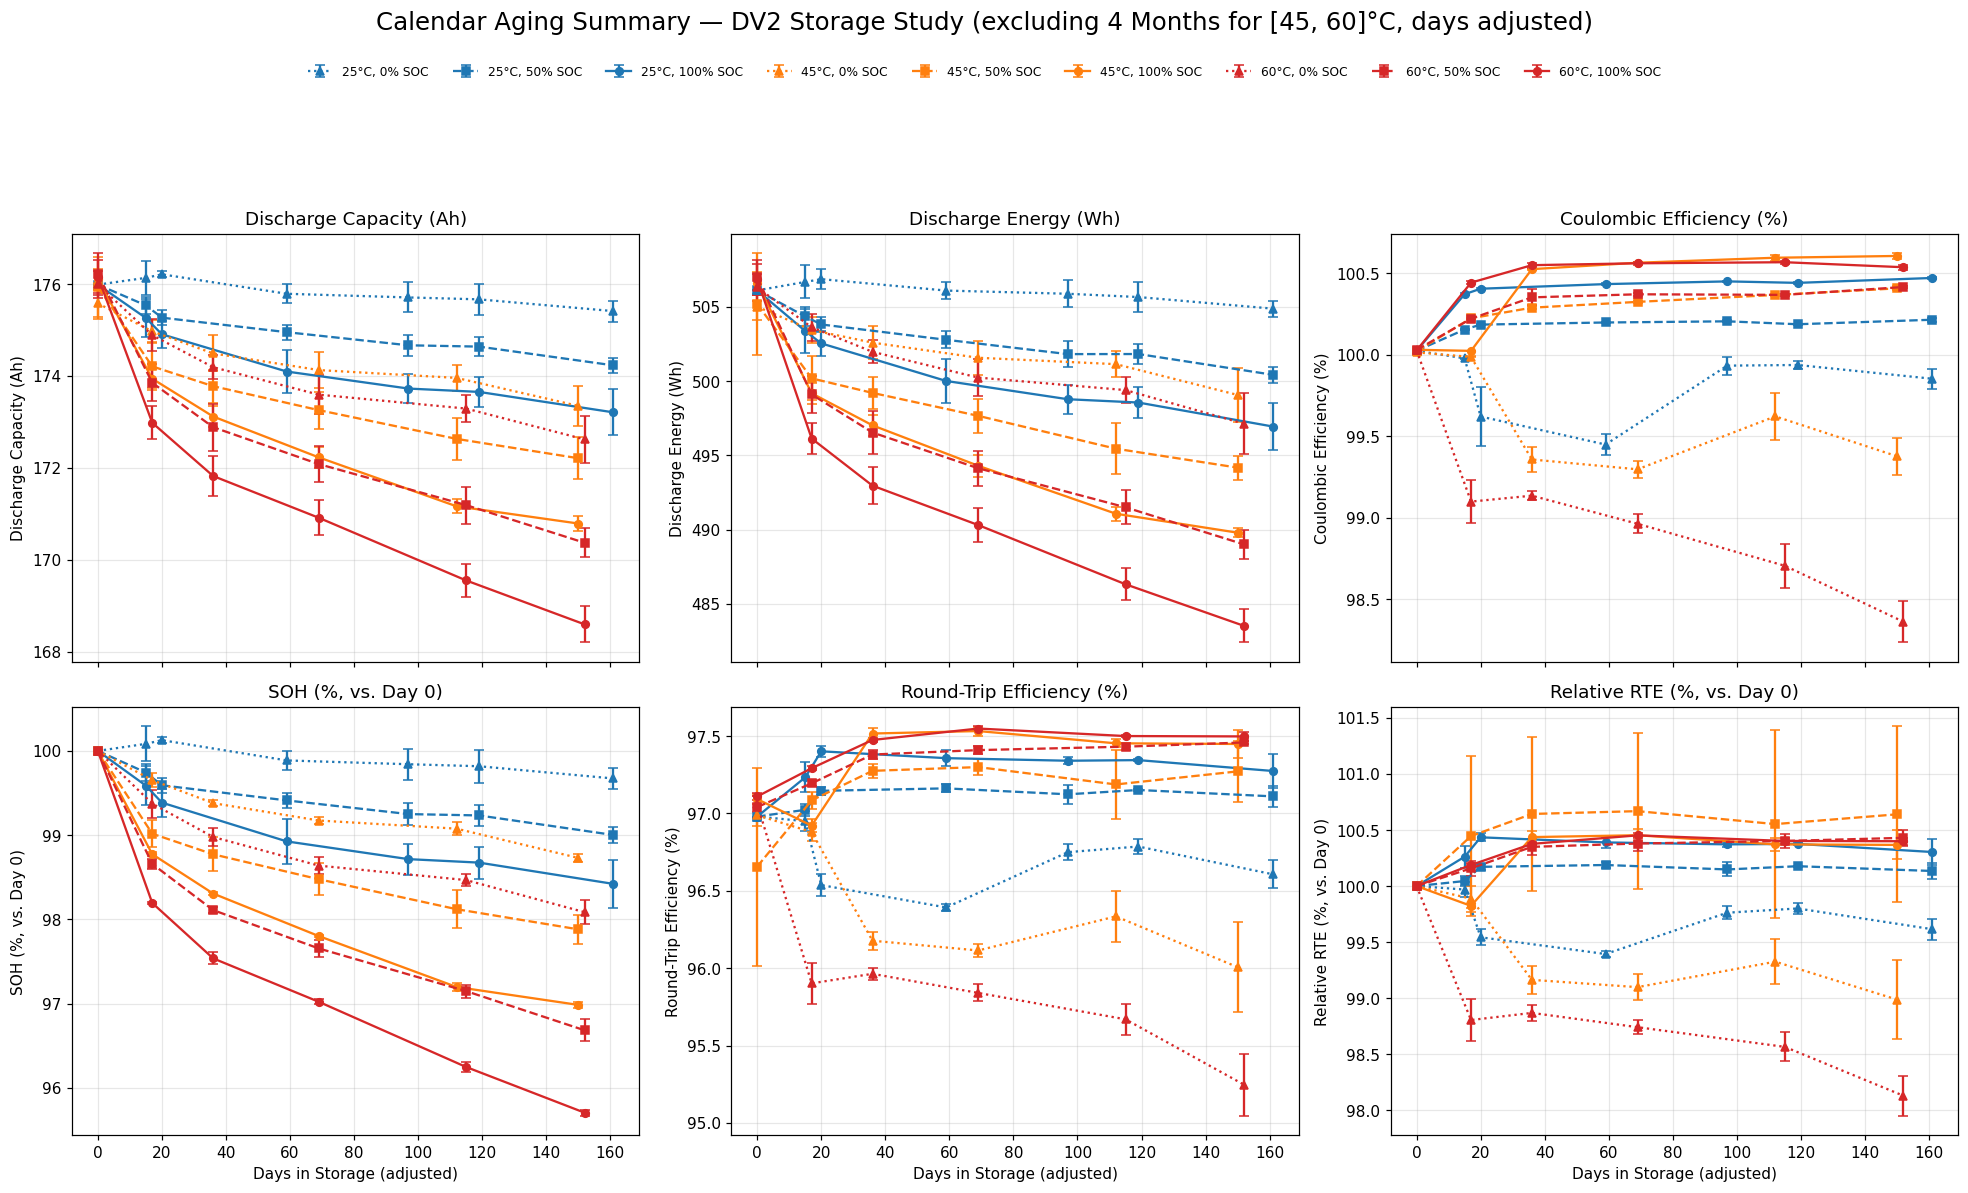

In [22]:
TEMP_COLORS = {25: "tab:blue", 45: "tab:orange", 60: "tab:red"}
SOC_STYLES = {100: ("-", "o"), 50: ("--", "s"), 0: (":", "^")}

summary["Temp_C"] = summary["Temperature"].map(temp_to_num)
summary["SOC_pct"] = summary["SOC_Group"].map(soc_to_num)

panels = [
    ("DischargeCapacity_Ah", "DischargeCapacity_Ah_std", "Discharge Capacity (Ah)"),
    ("DischargeEnergy_Wh", "DischargeEnergy_Wh_std", "Discharge Energy (Wh)"),
    ("CoulombicEfficiency_pct", "CoulombicEfficiency_pct_std", "Coulombic Efficiency (%)"),
    ("SOH_pct", "SOH_pct_std", "SOH (%, vs. Day 0)"),
    ("RTE_pct", "RTE_pct_std", "Round-Trip Efficiency (%)"),
    ("RelativeRTE_pct", "RelativeRTE_pct_std", "Relative RTE (%, vs. Day 0)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

groups = summary.groupby(["Temp_C", "SOC_pct"])
for ax, (col, std_col, title) in zip(axes.flat, panels):
    for (temp_c, soc_pct), grp in groups:
        grp = grp.sort_values("Days")
        color = TEMP_COLORS.get(temp_c, "gray")
        linestyle, marker = SOC_STYLES.get(soc_pct, ("-", "x"))
        ax.errorbar(
            grp["Days"], grp[col], yerr=grp[std_col],
            color=color, linestyle=linestyle, marker=marker,
            markersize=5, capsize=3, linewidth=1.5,
            label=f"{temp_c}°C, {soc_pct}% SOC",
        )
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel("Days in Storage (adjusted)" if EXCLUDED_BUCKETS else "Days in Storage")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=9, bbox_to_anchor=(0.5, 1.04),
           fontsize=8, frameon=False)
title_suffix = (
    f" (excluding {', '.join(EXCLUDED_BUCKETS)} for {EXCLUSION_TEMPERATURES}°C, "
    "days adjusted)"
    if EXCLUDED_BUCKETS else ""
)
fig.suptitle(f"Calendar Aging Summary — DV2 Storage Study{title_suffix}", y=1.08, fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
print(f"Figure saved to {FIGURE_PATH}")
plt.show()

## Step 6 — Export an ensemble-data workbook (v3 column set)

Writes one Excel workbook: a **Metadata** sheet (one row per cell) plus
one sheet per cell with a per-checkpoint time series using the v3 column
list. Two kinds of "unavailable" are distinguished:

- **Structurally inapplicable** columns for this calendar test — Cycle,
  ΔV, DCIR, Ambient/max temperatures, thickness — are filled with the
  literal string `"NAN"` for every row.
- **Not measured for this specific row** (e.g. Retained Discharge
  Capacity/Self Discharge at Baseline, or for 0%-SOC cells) is left as a
  real blank/NaN, since the column itself is meaningful for other rows.

Built from `tidy_analysis`, so excluded checkpoints are absent and
"Time (days)" reflects the adjusted elapsed days for the affected
temperatures.

In [ ]:
NAN_LABEL = "NAN"  # literal placeholder for any missing value — both structurally
                    # inapplicable columns AND individual missing data points
                    # (e.g. Baseline's Retained Discharge Capacity, or Self
                    # Discharge for 0%-SOC cells) are written as this string,
                    # never left as a blank cell, so downstream tooling that
                    # parses this workbook never hits an empty cell.

METADATA_COLUMNS = [
    "Test", "Cell number", "Serial number", "Temperature", "Test type",
    "P-rate", "Storage SOC", "File/folder", "Type note",
    "Specific notes", "General notes",
]

REFERENCE_COLUMNS_V3 = [
    "Time (days)", "Cycle", "Retained discharge capacity (Ah)",
    "Recovered charge capacity (Ah)", "Recovered discharge capacity (Ah)",
    "Relative retained discharge capacity", "Relative discharge capacity",
    "Self discharge (Ah)", "Coulombic efficiency",
    "Retained discharge energy (Wh)", "Recovered charge energy (Wh)",
    "Recovered discharge energy (Wh)", "Relative retained discharge energy",
    "Relative discharge energy", "Energy efficiency", "Energy inefficiency",
    "Relative energy efficiency", "Relative energy inefficiency",
    "Time weighted deltaV (mV)", "Capacity weighted deltaV (mV)",
    "Relative time weighted deltaV", "Relative capacity weighted deltaV",
    "Ambient temperature (°C)", "Max charge temperature (°C)",
    "Max discharge temperature (°C)", "10s DCIR 50%SOC (mOhms)",
    "SOC weighted 10s DCIR (mOhms)", "Relative 10s DCIR 50%SOC",
    "Relative SOC weighted 10s DCIR", "Thickness (mm)", "Relative thickness",
]


def build_metadata_rows(tidy_df):
    # First-seen order of each CellID matches the original "No." ordering
    # in the source workbook.
    cell_order = tidy_df.drop_duplicates(subset="CellID")[["CellID", "Temperature", "SOC_Group"]]
    cell_order = cell_order.reset_index(drop=True)

    rows = []
    for i, r in cell_order.iterrows():
        rows.append([
            f"Cell {i + 1}",
            i + 1,
            r["CellID"],
            temp_to_num(r["Temperature"]),
            "CaLT",
            NAN_LABEL,
            f"{soc_to_num(r['SOC_Group'])}% SOC",
            NAN_LABEL,
            NAN_LABEL,
            NAN_LABEL,
            NAN_LABEL,
        ])
    return cell_order, pd.DataFrame(rows, columns=METADATA_COLUMNS)


def _fill_blanks(row):
    """Replace any real NaN/None in a data row with the NAN_LABEL string.
    Leaves actual numeric values and existing NAN_LABEL strings untouched."""
    return [
        NAN_LABEL if (value is None or (isinstance(value, float) and pd.isna(value))) else value
        for value in row
    ]


def build_cell_sheet_rows_v3(cell_df):
    cell_df = cell_df.sort_values("Bucket")

    rows = []
    for _, r in cell_df.iterrows():
        row = [
            r["Days"],
            NAN_LABEL,                              # Cycle
            r["RetainedDischargeCapacity_Ah"],
            r["ChargeCapacity_Ah"],                 # Recovered Charge Capacity
            r["DischargeCapacity_Ah"],               # Recovered Discharge Capacity
            r["RelativeRetainedDischargeCapacity"],
            r["RelativeDischargeCapacity"],
            r["SelfDischarge_Ah"],
            r["CoulombicEfficiency_frac"],
            r["RetainedDischargeEnergy_Wh"],
            r["ChargeEnergy_Wh"],                    # Recovered Charge Energy
            r["DischargeEnergy_Wh"],                 # Recovered Discharge Energy
            r["RelativeRetainedDischargeEnergy"],
            r["RelativeDischargeEnergy"],
            r["EnergyEfficiency_frac"],
            r["EnergyInefficiency_frac"],
            r["RelativeEnergyEfficiency_frac"],
            r["RelativeEnergyInefficiency_frac"],
            NAN_LABEL, NAN_LABEL, NAN_LABEL, NAN_LABEL,  # ΔV (time/capacity weighted) + relatives
            NAN_LABEL, NAN_LABEL, NAN_LABEL,              # Ambient/max charge/max discharge temp
            NAN_LABEL, NAN_LABEL, NAN_LABEL, NAN_LABEL,  # 10s DCIR 50%SOC, SOC-weighted DCIR + relatives
            NAN_LABEL, NAN_LABEL,                        # Thickness, relative thickness
        ]
        rows.append(_fill_blanks(row))
    return rows


cell_order, metadata_df = build_metadata_rows(tidy_analysis)

with pd.ExcelWriter(ENSEMBLE_XLSX_PATH, engine="openpyxl") as writer:
    metadata_df.to_excel(writer, sheet_name="Metadata", index=False)

    for i, r in cell_order.iterrows():
        sheet_name = f"Cell {i + 1}"
        cell_df = tidy_analysis[tidy_analysis["CellID"] == r["CellID"]]
        data_rows = build_cell_sheet_rows_v3(cell_df)

        header_row = [r["CellID"]] + [np.nan] * (len(REFERENCE_COLUMNS_V3) - 1)
        sheet_matrix = [header_row, REFERENCE_COLUMNS_V3] + data_rows
        pd.DataFrame(sheet_matrix).to_excel(writer, sheet_name=sheet_name, header=False, index=False)

print(f"Ensemble-data workbook written to {ENSEMBLE_XLSX_PATH}")
print(f"  Metadata: {len(metadata_df)} cells")
print(f"  Per-cell sheets: Cell 1 .. Cell {len(cell_order)}")
if EXCLUDED_BUCKETS:
    print(f"  Excluded checkpoints: {EXCLUDED_BUCKETS} (for {EXCLUSION_TEMPERATURES}°C, "
          "days adjusted accordingly)")